In [34]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
from rasterio.features import shapes
import rasterio
from shapely.geometry import shape

In [35]:
basins_eu_me = gpd.read_file("../data/hybas_eu_lev01-06_v1c/hybas_eu_lev04_v1c.shp")
rivers_eu = gpd.read_file("../data/HydroRIVERS_v10_eu_shp/HydroRIVERS_v10_eu.shp")
countries = gpd.read_file("../data/world-administrative-boundaries/world-administrative-boundaries.shp")
mines = gpd.read_file("../data/mine_polygons/74548_projected polygons.shp")
flo_IPB = xr.open_dataset("../data/flo_IPB_last_date.nc")


In [36]:
mask_strahler_five = rivers_eu["ORD_STRA"] >= 5
rivers_eu_five = rivers_eu[mask_strahler_five]

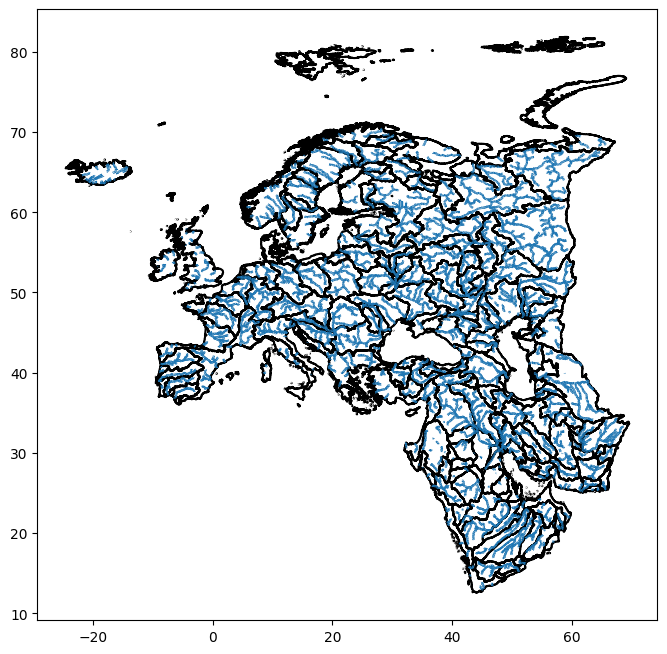

In [37]:
ax = basins_eu_me.boundary.plot(edgecolor = "k", figsize= (8, 8))
rivers_eu_five.plot(ax = ax);

In [38]:
IPB = basins_eu_me.iloc[45:53]
spain_mask  = countries["English_Nam"] == "Spain" 
portugal_mask = countries["English_Nam"] == "Portugal"
mask_iberia = spain_mask | portugal_mask
iberia = countries[mask_iberia]

In [39]:
rivers_in_IPB = gpd.sjoin(rivers_eu, IPB, predicate='intersects', how='inner')

In [40]:
print(flo_IPB["qav"].values.max())
print(flo_IPB["qav"].values.min())

nan
nan


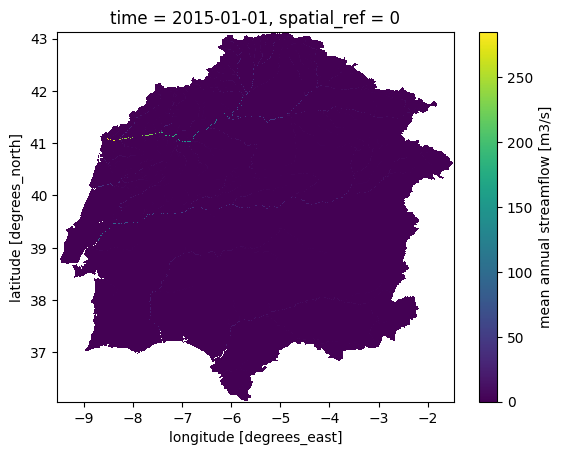

In [41]:
flo_IPB["qav"].plot()

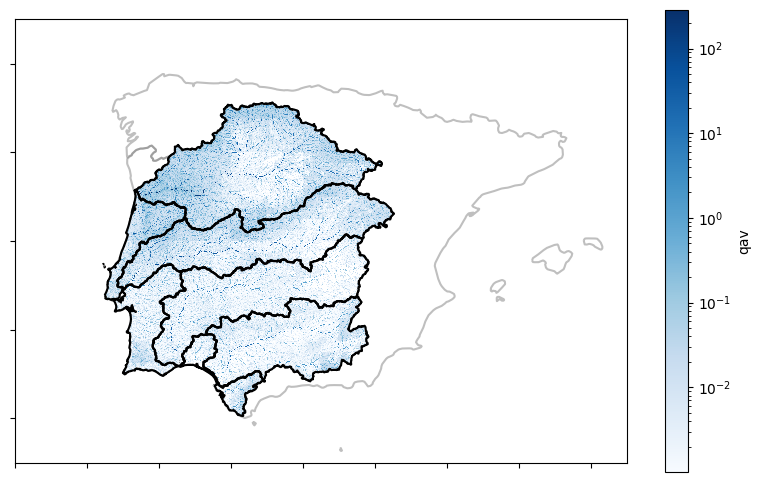

In [42]:
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize = (8, 8))

IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)

flo_IPB_plot = flo_IPB["qav"].where(flo_IPB["qav"] > 0)
norm = mcolors.LogNorm(vmin=flo_IPB_plot.min(), vmax=flo_IPB_plot.max())
flo_IPB_plot.plot(ax = ax, cmap = "Blues",  norm = norm, cbar_kwargs={'shrink': 0.6, 'label': 'qav'})
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_flo1k.png", dpi = 200)
plt.show()
plt.close()

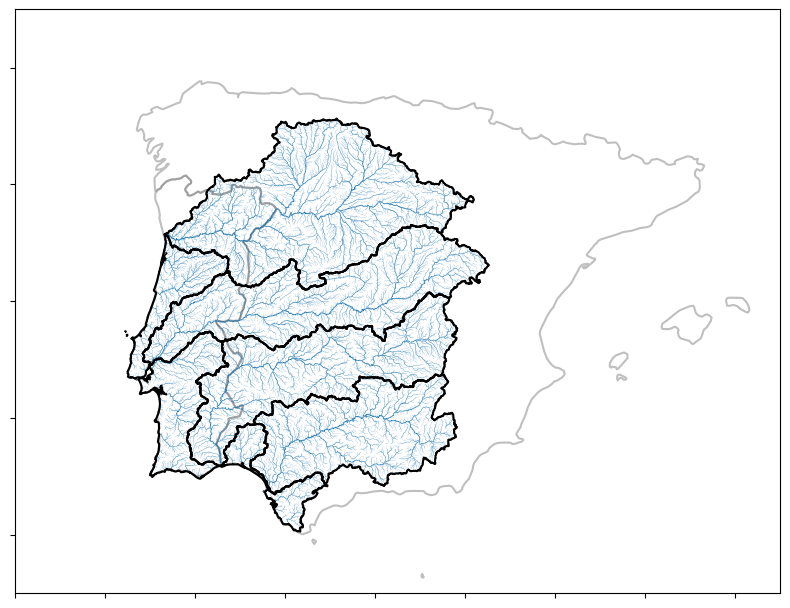

In [43]:
fig, ax = plt.subplots(figsize = (8, 8))
sizes = rivers_in_IPB["ORD_STRA"].fillna(1).astype(float) * 0.1
IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)
rivers_in_IPB.plot(ax = ax,linewidth=sizes)
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_hydrorivers.png", dpi = 200)
plt.show()
plt.close()

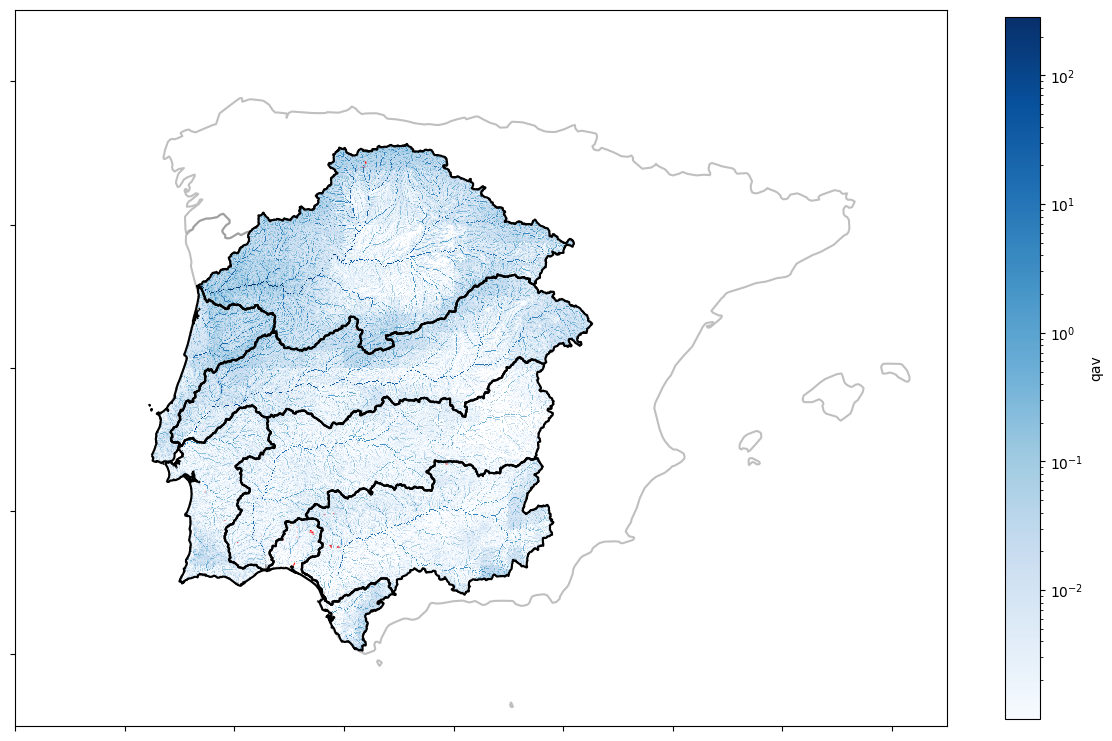

In [44]:
mines.to_crs(4326, inplace = True)
IPB_mines = gpd.sjoin(mines, IPB, predicate='intersects', how='inner')

fig, ax = plt.subplots(figsize = (12, 12))

IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)

flo_IPB_plot = flo_IPB["qav"].where(flo_IPB["qav"] > 0)
norm = mcolors.LogNorm(vmin=flo_IPB_plot.min(), vmax=flo_IPB_plot.max())
flo_IPB_plot.plot(ax = ax, cmap = "Blues",  norm = norm, cbar_kwargs={'shrink': 0.6, 'label': 'qav'})
IPB_mines.plot(ax = ax, color = "red")
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_flo1k_mines.png", dpi = 200)
plt.show()
plt.close()


In [45]:
mines_raster = xr.open_dataset("../data/mines_raster_IPB.tif")
mines_raster

<xarray.Dataset> Size: 3MB
Dimensions:      (band: 1, x: 970, y: 848)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 8kB -9.546 -9.538 -9.529 ... -1.487 -1.479 -1.471
  * y            (y) float64 7kB 36.06 36.07 36.08 36.09 ... 43.1 43.11 43.12
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 3MB ...

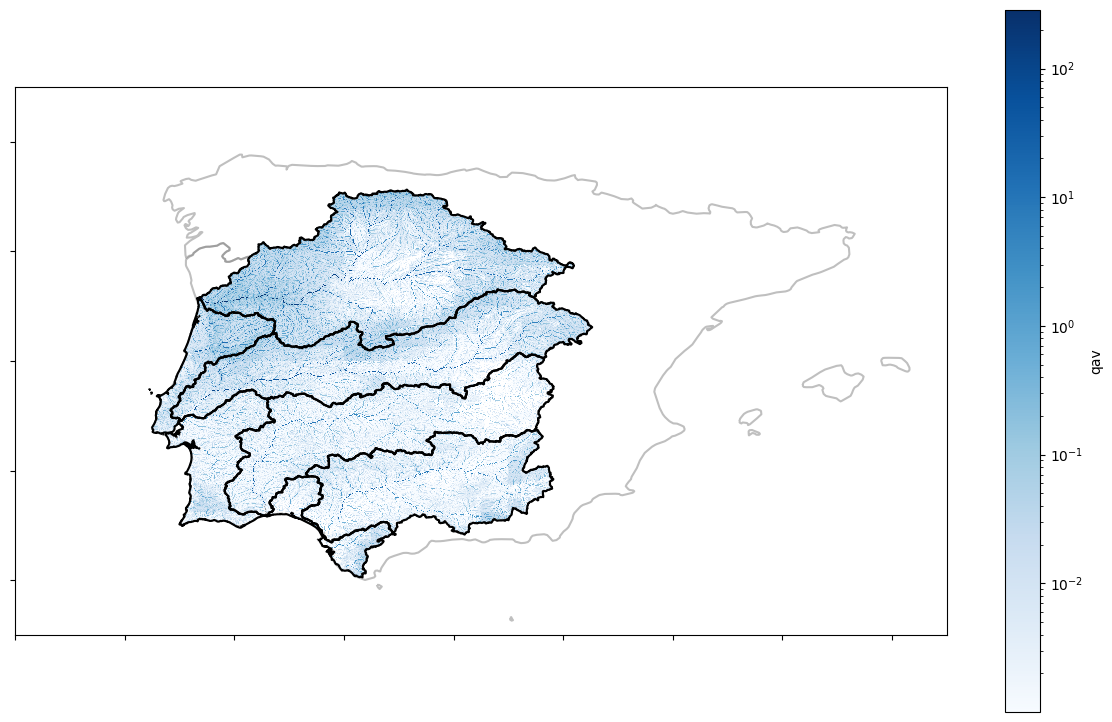

In [54]:
fig, ax = plt.subplots(figsize = (12, 12))

IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)

flo_IPB_plot = flo_IPB["qav"].where(flo_IPB["qav"] > 0)
norm = mcolors.LogNorm(vmin=flo_IPB_plot.min(), vmax=flo_IPB_plot.max())
flo_IPB_plot.plot(ax = ax, cmap = "Blues",  norm = norm, cbar_kwargs={'shrink': 0.6, 'label': 'qav'})

data = mines_raster['band_data'].squeeze()

colors = ['none', 'red']  # transparent, red
cmap = mcolors.ListedColormap(colors)

binary_data = (data > 0).astype(int)

ax.imshow(binary_data,
               cmap=cmap,)


ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_flo1k_mines.png", dpi = 200)
plt.show()
plt.close()